# An Ablation Study of QRC for Satellite Image Denoising — Pipeline (§II Methodology)

Runs the paper's full methodology for **one noise level σ** and saves per-image metric
arrays to `results/` for `02_analysis.ipynb`. σ is taken from the `QRC_SIGMA`
environment variable (default 0.7); run once per σ ∈ {0.1, 0.3, 0.5, 0.7}.

Pipeline: EuroSAT → grayscale → multiplicative noise → PCA(18) →
{MLP (baseline), QRC → MLP (hybrid)} → per-image MSE / SSIM / TENG.

Every heavy stage (dataset download, reservoir embeddings, trained models) is cached
and skipped when its output already exists.

In [40]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
import random
import subprocess
import sys
import time
import urllib.request
import zipfile
from dataclasses import dataclass
from pathlib import Path

import joblib
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src import plots

# ── Experiment config ─────────────────────────────────────────────────────────
SIGMA = float(os.environ.get("QRC_SIGMA", 0.7))  # multiplicative noise std
D_QRC = 18            # qubits = PCA components fed to the reservoir
SEED  = 42

N_COMPONENTS   = 100  # PCA components computed (first D_QRC used downstream)
LEARNING_RATE  = 1e-4
DROPOUT_RATE   = 0.3
BATCH_SIZE     = 64
EPOCHS         = 500
PATIENCE       = 20
BATCH_SIZE_QRC = 32    # GPU reservoir batch
CHEB_TOL       = 1e-7  # Chebyshev coefficient cutoff
TENG_THRESHOLD = 0.05  # images in [0, 1]; same T for both models

EUROSAT_URL = "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip"
DATA_DIR    = Path("data/EuroSAT_RGB")
ZIP_PATH    = Path("data/EuroSAT_RGB.zip")
MODEL_DIR   = Path("models")
RESULTS_DIR = Path("results")
for _p in (MODEL_DIR, RESULTS_DIR):
    _p.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
for _g in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_g, True)  # 4 GB GPU: grow on demand

print(f"σ = {SIGMA}, d = {D_QRC}, GPU: {tf.config.list_physical_devices('GPU')}")

σ = 0.7, d = 18, GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## II. Methodology

### A. Data, Noise, and Classical Baseline

EuroSAT images are converted to grayscale (Rec.601 luminance), normalized to $[0, 1]$,
and flattened. Data is split into train, validation, and test sets (8:1:1 ratio,
stratified by land-cover class).

In [41]:
def to_grayscale(X_rgb):
    """Rec.601 luminance. Input: (..., 3) float32. Output: (...) float32."""
    return 0.299 * X_rgb[..., 0] + 0.587 * X_rgb[..., 1] + 0.114 * X_rgb[..., 2]


if not (DATA_DIR.exists() and any(DATA_DIR.iterdir())):
    if not ZIP_PATH.exists():
        ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
        print(f"Downloading EuroSAT RGB from {EUROSAT_URL} ...")
        urllib.request.urlretrieve(EUROSAT_URL, ZIP_PATH)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR.parent)

CATEGORIES = sorted(p.name for p in DATA_DIR.iterdir() if p.is_dir())
images, labels = [], []
for li, cat in enumerate(CATEGORIES):
    for path in sorted((DATA_DIR / cat).glob("*.jpg")):
        images.append(np.array(Image.open(path).resize((64, 64)), dtype=np.float32) / 255.0)
        labels.append(li)

X = to_grayscale(np.stack(images))  # (N, 64, 64)
labels = np.array(labels)
print(f"{len(CATEGORIES)} categories, total: {X.shape}")

# 80% train, 10% val, 10% test — stratified
X_train, X_temp, l_train, l_temp = train_test_split(
    X, labels, test_size=0.2, random_state=SEED, stratify=labels)
X_val, X_test, l_val, l_test = train_test_split(
    X_temp, l_temp, test_size=0.5, random_state=SEED, stratify=l_temp)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Clean flattened targets in [0, 1] — shared by both models
y_train = X_train.reshape(len(X_train), -1).astype(np.float32)
y_val   = X_val.reshape(len(X_val), -1).astype(np.float32)
y_test  = X_test.reshape(len(X_test), -1).astype(np.float32)

10 categories, total: (27000, 64, 64)
Train: (21600, 64, 64), Val: (2700, 64, 64), Test: (2700, 64, 64)


Multiplicative artificial noise: each pixel is scaled by $1 + \epsilon_i$ with
$\epsilon_i \sim \mathcal{N}(0, \sigma^2)$, and the result clipped to $[0, 1]$ —
the noise model of Das et al., extended here to a sweep over σ. Each split uses its own
noise seed.

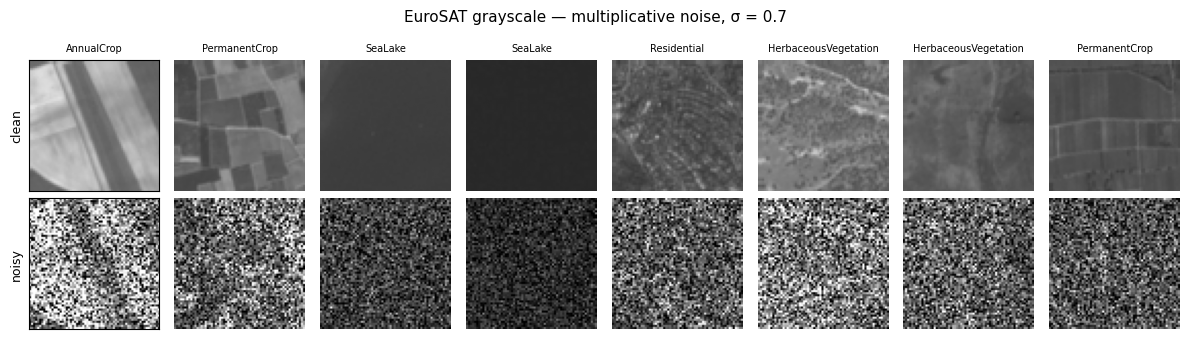

In [42]:
def apply_noise(X, sigma, seed):
    """I~ = clip(I · (1 + σ · N(0,1)), 0, 1). X must be float32 in [0, 1]."""
    rng = np.random.default_rng(seed)
    eps = rng.normal(0, sigma, size=X.shape).astype(np.float32)
    return np.clip(X * (1 + eps), 0.0, 1.0)


X_train_noisy = apply_noise(X_train, sigma=SIGMA, seed=SEED)
X_val_noisy   = apply_noise(X_val,   sigma=SIGMA, seed=SEED + 1)
X_test_noisy  = apply_noise(X_test,  sigma=SIGMA, seed=SEED + 2)

plots.image_rows([(X_train[:8], "clean"), (X_train_noisy[:8], "noisy")],
                 col_titles=[CATEGORIES[l] for l in l_train[:8]],
                 suptitle=f"EuroSAT grayscale — multiplicative noise, σ = {SIGMA}")

PCA is fitted **exclusively on the clean training images**; noisy splits are
projected onto the computed axes. Due to the $2^N$ exponential scaling of classical QRC
simulation, the input bottleneck is restricted to the first $d = 18$ principal
components, min-max scaled to $[0, 1]$ on training statistics (the reservoir detuning
encoding expects inputs in $[0, 1]$).

PC1 explained variance:  66.91%   (paper §IV)
First 18 PCs cumulative: 81.08%
All 100 PCs cumulative: 89.83%


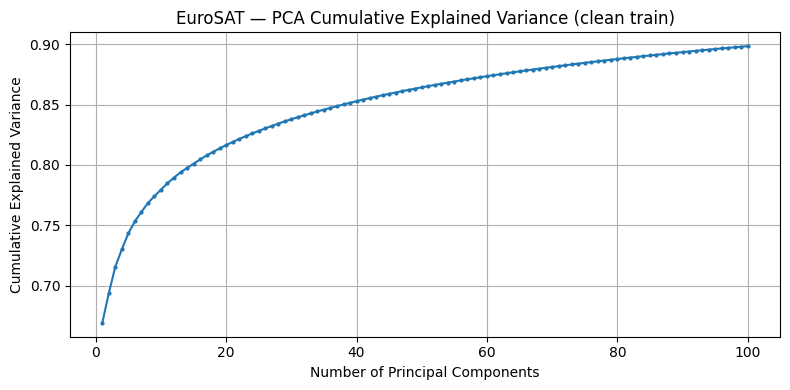

corr(PC1, mean brightness), clean train:      |r| = 1.0000
cos(PC1 loading, uniform direction):          |cos| = 0.9994
corr(PC1, mean brightness), noisy test σ=0.7: |r| = 1.0000


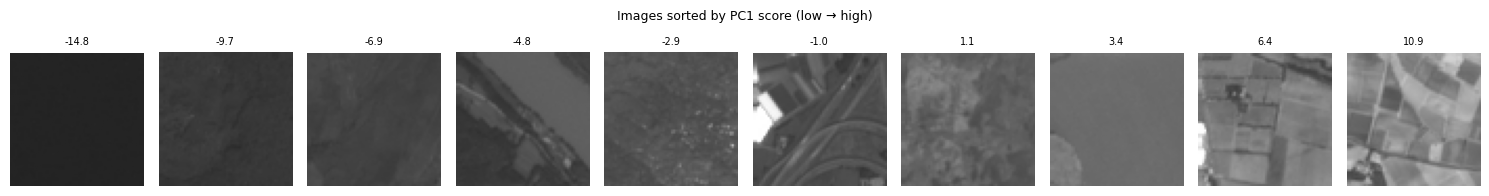

QRC inputs: {'train': (21600, 18), 'val': (2700, 18), 'test': (2700, 18)}


In [43]:
pca = PCA(n_components=N_COMPONENTS)
pca.fit(X_train.reshape(len(X_train), -1))

evr = pca.explained_variance_ratio_
print(f"PC1 explained variance:  {100 * evr[0]:.2f}%   (paper §IV)")
print(f"First {D_QRC} PCs cumulative: {100 * evr[:D_QRC].sum():.2f}%")
print(f"All {N_COMPONENTS} PCs cumulative: {100 * evr.sum():.2f}%")
plots.explained_variance(evr)
# PC1 ≈ brightness — the shortcut discussed in paper §IV. Visual check plus
# quantitative backing: Pearson r between PC1 score and mean pixel intensity,
# and cosine of the PC1 loading vector against the uniform (pure-brightness)
# direction in pixel space. Signs are arbitrary (PCA sign convention).
from scipy.stats import pearsonr

Xf_train = X_train.reshape(len(X_train), -1)
pc1_train = pca.transform(Xf_train)[:, 0]
pc1_brightness_r = pearsonr(pc1_train, Xf_train.mean(axis=1)).statistic
u = np.full(Xf_train.shape[1], 1.0 / np.sqrt(Xf_train.shape[1]))
pc1_uniform_cos = float(pca.components_[0] @ u)

Xf_test_noisy = X_test_noisy.reshape(len(X_test_noisy), -1)
pc1_brightness_r_noisy = pearsonr(
    pca.transform(Xf_test_noisy)[:, 0], Xf_test_noisy.mean(axis=1)).statistic

print(f"corr(PC1, mean brightness), clean train:      |r| = {abs(pc1_brightness_r):.4f}")
print(f"cos(PC1 loading, uniform direction):          |cos| = {abs(pc1_uniform_cos):.4f}")
print(f"corr(PC1, mean brightness), noisy test σ={SIGMA}: |r| = {abs(pc1_brightness_r_noisy):.4f}")
plots.pc1_extremes(X_train, pc1_train)

# First D_QRC components of the noisy splits, min-max scaled on train statistics
z = {name: pca.transform(Xn.reshape(len(Xn), -1))[:, :D_QRC]
     for name, Xn in (("train", X_train_noisy), ("val", X_val_noisy), ("test", X_test_noisy))}
z_min, z_max = z["train"].min(axis=0), z["train"].max(axis=0)


def scale_z(v, eps=1e-8):
    return np.clip((v - z_min) / (z_max - z_min + eps), 0.0, 1.0).astype(np.float64)


z = {k: scale_z(v) for k, v in z.items()}
print("QRC inputs:", {k: v.shape for k, v in z.items()})

The classical baseline feeds the 18 standardized PCs into an MLP denoiser: four
hidden layers (1024, 2048, 4096, 8192 nodes) with ReLU activations and dropout 0.3,
followed by a sigmoid output layer with 4096 nodes (64×64). Both models train with Adam
(learning rate $10^{-4}$), MSE loss, batch size 64, and early-stopping patience of 20
epochs.

Training runs in a **subprocess** (`train_readout.py`, the single source of the
architecture) so TensorFlow releases all GPU memory between the two models — required on
a 4 GB GPU. Cached models are loaded instead of retrained.

In [44]:
from keras.models import load_model
from train_readout import build_model

with tf.device("/CPU:0"):  # keep the kernel off the GPU: the training subprocess needs the whole card
    build_model(D_QRC, DROPOUT_RATE).summary()  # input width: 18 (baseline) / 1368 (hybrid)


def train_or_load(path, tag, x=None, y=None, xv=None, yv=None):
    """Load a cached model, or train it in a subprocess and load the result."""
    if not path.exists():
        ad = MODEL_DIR / "_arrays"
        ad.mkdir(parents=True, exist_ok=True)
        for name, arr in (("x", x), ("y", y), ("xv", xv), ("yv", yv)):
            np.save(ad / f"{tag}_{name}.npy", arr)
        cmd = [sys.executable, "train_readout.py",
               "--x", str(ad / f"{tag}_x.npy"), "--y", str(ad / f"{tag}_y.npy"),
               "--xval", str(ad / f"{tag}_xv.npy"), "--yval", str(ad / f"{tag}_yv.npy"),
               "--out", str(path),
               "--epochs", str(EPOCHS), "--batch", str(BATCH_SIZE),
               "--lr", str(LEARNING_RATE), "--dropout", str(DROPOUT_RATE),
               "--patience", str(PATIENCE)]
        print(f"{tag}: training in subprocess:\n  {' '.join(cmd)}", flush=True)
        subprocess.run(cmd, check=True)
    print(f"{tag}: loading {path}")
    with tf.device("/CPU:0"):
        return load_model(path)


pca_scaler = StandardScaler()
Zb_train = pca_scaler.fit_transform(z["train"]).astype(np.float32)
Zb_val   = pca_scaler.transform(z["val"]).astype(np.float32)
Zb_test  = pca_scaler.transform(z["test"]).astype(np.float32)

baseline = train_or_load(MODEL_DIR / f"sigma{SIGMA}_mlp_baseline_d{D_QRC}.keras",
                         "baseline", Zb_train, y_train, Zb_val, y_val)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 1024)           │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8192)           │    33,562,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4096)           │    33,558,528 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,632,512 (296.14 MB)

 Trainable params: 77,632,512 (296.14 MB)

 Non-trainable params: 0 (0.00 B)

baseline: loading models/sigma0.7_mlp_baseline_d18.keras


### B. Hybrid Quantum Pipeline

The hybrid pipeline inserts a QRC step between PCA and the MLP. Each of the $d = 18$
reduced features is mapped to one qubit of a one-dimensional array of interacting
Rydberg atoms (Das et al.). A **time-independent** Ising-type Hamiltonian, with
input-dependent local detunings, drives the system's quench dynamics:

$$H(z) = \Omega \sum_i X_i + \sum_i \frac{\Delta_i(z_i)}{2} Z_i + \sum_{i<j} V_{ij} \, n_i n_j$$

with $\Delta_i(z_i) = \Delta_0 - k \cdot z_i$, $V_{ij} = V_0 / |i-j|^6$,
$n_i = (1+Z_i)/2$; $\Omega = 2\pi$, $\Delta_0 = 4.5$, $k = 9.0$, $V_0 = 5.42$ rad/μs
(10 μm lattice spacing).

Single-atom expectation values $\langle Z_i \rangle$ and pairwise correlations
$\langle Z_i Z_j \rangle$ are computed at $L = 8$ successive evolution times
($dt = 0.5$ μs), extracting $R = L\,(d + d(d-1)/2) = 8 \cdot 171 = 1368$ features.
Expectation values are computed **exactly from the simulated statevector**, without
measurement shot noise.

Implementation: a CPU reference (`scipy.sparse` + `expm_multiply`, exact) and a GPU
Chebyshev propagation of $e^{-iH\,dt}$ (TensorFlow sparse ops), verified against the
CPU reference to fp32 tolerance. Embeddings are cached to `models/` (≈ 4 h on a 4 GB
GPU for all 27 000 images).

In [45]:
@dataclass
class QRCConfig:
    n_qubits: int = 18
    n_steps: int = 8
    dt: float = 0.5
    omega: float = 2 * np.pi       # Rabi frequency (rad/μs)
    global_detuning: float = 4.5   # Δ₀ (rad/μs)
    detuning_scale: float = 9.0    # k  (rad/μs)
    interaction_strength: float = 5.42  # rad/μs: C6/a^6, C6/2π=862690 MHz·μm⁶, a=10μm spacing
    interaction_power: float = 6.0
    shots: int | None = None       # None = exact expectation values
    seed: int = SEED


class RydbergReservoir:
    """1D Rydberg-atom chain quantum reservoir (CPU reference, exact).

    H_fixed is built once; per-image cost is a diagonal update + n_steps expm_multiply calls.
    """

    def __init__(self, config):
        from scipy.sparse import csr_matrix, diags

        self.cfg = config
        n, dim = config.n_qubits, 2 ** config.n_qubits
        self.dim = dim
        self.rng = np.random.default_rng(config.seed)

        # Z eigenvalue vectors: Z_eigs[i, state] = ±1
        self._Z_eigs = np.stack([self._z_eig(i, n, dim) for i in range(n)])  # (n, dim)
        self._H_fixed = self._build_H_fixed()

        # Observable diagonals: ⟨Zᵢ⟩ then ⟨ZᵢZⱼ⟩ for all i<j
        self._obs = list(self._Z_eigs)
        for i in range(n):
            for j in range(i + 1, n):
                self._obs.append(self._Z_eigs[i] * self._Z_eigs[j])

        n_obs = len(self._obs)
        self.embed_dim = config.n_steps * n_obs
        print(f"RydbergReservoir: d={n}, dim={dim}, "
              f"obs={n_obs} ({n} Z + {n*(n-1)//2} ZZ), embed_dim={self.embed_dim}")

    @staticmethod
    def _z_eig(qubit, n_qubits, dim):
        """Eigenvalues of Z_qubit in the computational basis (big-endian)."""
        mask = 1 << (n_qubits - 1 - qubit)
        idx = np.arange(dim)
        bit = (idx & mask) >> (n_qubits - 1 - qubit)
        return (1 - 2 * bit).astype(np.float64)

    @staticmethod
    def _x_sparse(qubit, n_qubits, dim):
        """Sparse Pauli-X on one qubit."""
        from scipy.sparse import csr_matrix

        mask = 1 << (n_qubits - 1 - qubit)
        row = np.arange(dim)
        col = row ^ mask
        return csr_matrix((np.ones(dim, dtype=np.complex128), (row, col)), shape=(dim, dim))

    def _build_H_fixed(self):
        """H_fixed = Ω Σᵢ Xᵢ + 0.5 Δ₀ Σᵢ Zᵢ + Σᵢ<ⱼ Vᵢⱼ[0.25 Zᵢ + 0.25 Zⱼ + 0.25 ZᵢZⱼ] (nᵢnⱼ expansion)."""
        from scipy.sparse import csr_matrix, diags

        cfg = self.cfg
        n, dim = cfg.n_qubits, self.dim

        H = csr_matrix((dim, dim), dtype=np.complex128)
        for i in range(n):
            H = H + cfg.omega * self._x_sparse(i, n, dim)

        diag = np.zeros(dim, dtype=np.float64)
        for i in range(n):
            diag += 0.5 * cfg.global_detuning * self._Z_eigs[i]
        for i in range(n):
            for j in range(i + 1, n):
                vij = cfg.interaction_strength / (abs(j - i) ** cfg.interaction_power)
                diag += 0.25 * vij * self._Z_eigs[i]
                diag += 0.25 * vij * self._Z_eigs[j]
                diag += 0.25 * vij * self._Z_eigs[i] * self._Z_eigs[j]

        return H + diags(diag.astype(np.complex128))

    def _data_diag(self, z):
        """Data-dependent diagonal: -0.5 · k · Σᵢ zᵢ Zᵢ (Δ₀ part already in H_fixed)."""
        return (-0.5 * self.cfg.detuning_scale) * (z @ self._Z_eigs)

    def transform_one(self, z):
        """z: (n_qubits,) in [0, 1] → embedding (embed_dim,)."""
        from scipy.sparse import diags
        from scipy.sparse.linalg import expm_multiply

        H = self._H_fixed + diags(self._data_diag(z).astype(np.complex128))
        state = np.zeros(self.dim, dtype=np.complex128)
        state[0] = 1.0  # ground state |0...0⟩

        features = []
        for _ in range(self.cfg.n_steps):
            state = expm_multiply(-1j * H * self.cfg.dt, state)
            probs = np.abs(state) ** 2
            probs /= probs.sum()
            if self.cfg.shots is None:
                features.extend(float(np.dot(probs, obs)) for obs in self._obs)
            else:
                samples = self.rng.choice(self.dim, size=self.cfg.shots, p=probs)
                features.extend(float(obs[samples].mean()) for obs in self._obs)

        return np.array(features, dtype=np.float64)

In [46]:
from scipy.special import jv


class TFReservoir:
    """GPU reservoir: Chebyshev propagation of exp(-iH·dt) for a batch of images.

    Reuses the CPU reservoir's fixed Hamiltonian, Z eigenvalues and observables.
    Per-image detuning enters as a data-dependent diagonal D added to H_fixed.
    """

    def __init__(self, reservoir, cfg):
        self.n       = cfg.n_qubits
        self.dim     = reservoir.dim
        self.n_steps = cfg.n_steps
        self.dt      = cfg.dt
        self.k       = cfg.detuning_scale
        self.R       = self.n * cfg.omega

        Hc = reservoir._H_fixed.tocoo()
        idx = np.stack([Hc.row, Hc.col], 1).astype(np.int64)
        self.Hsp = tf.sparse.reorder(
            tf.SparseTensor(idx, Hc.data.astype(np.complex64), [self.dim, self.dim])
        )
        self.Hdiag   = tf.constant(reservoir._H_fixed.diagonal().real.astype(np.float32)[:, None])
        self.Z       = tf.constant(reservoir._Z_eigs.astype(np.complex64))
        self.obs_mat = tf.constant(np.stack(reservoir._obs).astype(np.float32))
        self.embed_dim = reservoir.embed_dim

    def embed_batch(self, z_batch, tol=CHEB_TOL):
        dt, dim, B = self.dt, self.dim, z_batch.shape[0]
        zc = tf.constant(z_batch.astype(np.complex64))
        D  = tf.transpose((-0.5 * self.k) * tf.matmul(zc, self.Z))
        full = self.Hdiag + tf.math.real(D)
        Emax = float(tf.reduce_max(full)) + self.R
        Emin = float(tf.reduce_min(full)) - self.R
        c, Delta = (Emax + Emin) / 2.0, (Emax - Emin) / 2.0

        x  = Delta * dt
        K0 = int(np.ceil(x)) + 30
        ks = np.arange(K0 + 1)
        ak = (2.0 - (ks == 0)) * ((-1j) ** ks) * jv(ks, x)
        keep = np.where(np.abs(ak) > tol)[0]
        ak = (ak[:int(keep[-1]) + 1] * np.exp(-1j * c * dt)).astype(np.complex64)

        cI   = tf.constant(c, tf.complex64)
        invD = tf.constant(1.0 / Delta, tf.complex64)
        two  = tf.constant(2.0, tf.complex64)

        def Htil(v):
            return (tf.sparse.sparse_dense_matmul(self.Hsp, v) + D * v - cI * v) * invD

        state = tf.constant(np.eye(1, dim, 0, dtype=np.complex64).T * np.ones((1, B), np.complex64))
        feats = []
        for _ in range(self.n_steps):
            T0, T1 = state, Htil(state)
            out = ak[0] * T0 + ak[1] * T1
            for kk in range(2, len(ak)):
                T2  = two * Htil(T1) - T0
                out = out + ak[kk] * T2
                T0, T1 = T1, T2
            state = out
            pr = tf.math.real(state * tf.math.conj(state))
            pr = pr / tf.reduce_sum(pr, axis=0, keepdims=True)
            feats.append(tf.matmul(self.obs_mat, pr))
        return tf.transpose(tf.concat(feats, 0)).numpy()


def compute_embeddings_gpu(tf_reservoir, z_scaled, cache_path, batch_size=BATCH_SIZE_QRC):
    n = len(z_scaled)
    out = np.empty((n, tf_reservoir.embed_dim), dtype=np.float64)
    print(f"Computing {n} embeddings on GPU (batch={batch_size}) ...")
    t0 = time.perf_counter()
    for i in range(0, n, batch_size):
        out[i:i + batch_size] = tf_reservoir.embed_batch(z_scaled[i:i + batch_size])
        if (i // batch_size) % 20 == 0:
            done = min(i + batch_size, n)
            rate = (time.perf_counter() - t0) / done
            print(f"  {done}/{n}  ({rate:.3f}s/img, eta {rate*(n-done)/60:.1f} min)", flush=True)
    np.save(cache_path, out)
    print(f"Done in {(time.perf_counter()-t0)/60:.1f} min → saved to {cache_path}")
    return out


scaler_path  = RESULTS_DIR / f"sigma{SIGMA}_embed_scaler_d{D_QRC}.joblib"
readout_path = MODEL_DIR / f"sigma{SIGMA}_mlp_qrc_readout_d{D_QRC}.keras"

CACHE = {s: MODEL_DIR / f"sigma{SIGMA}_embeddings_d{D_QRC}_{s}.npy"
         for s in ("train", "val", "test")}

# With a trained readout + saved scaler, only the test embeddings are needed
need = ["test"] if readout_path.exists() and scaler_path.exists() else ["train", "val", "test"]
missing = [s for s in need if not CACHE[s].exists()]

if missing:
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    cfg = QRCConfig(n_qubits=D_QRC)
    reservoir = RydbergReservoir(cfg)
    tf_reservoir = TFReservoir(reservoir, cfg)
    # GPU vs CPU smoke check on 5 images (CPU reference is exact but slow)
    cpu_ref = np.array([reservoir.transform_one(v) for v in z["train"][:5]])
    max_err = np.abs(tf_reservoir.embed_batch(z["train"][:5]) - cpu_ref).max()
    print(f"GPU vs CPU smoke — max abs error: {max_err:.2e}")
    assert max_err < 5e-3, "GPU reservoir disagrees with CPU reference beyond fp32 tolerance"

R = {s: np.load(CACHE[s]) if CACHE[s].exists()
     else compute_embeddings_gpu(tf_reservoir, z[s], CACHE[s])
     for s in need}
print("Embeddings:", {k: v.shape for k, v in R.items()})

Embeddings: {'train': (21600, 1368), 'val': (2700, 1368), 'test': (2700, 1368)}


Reservoir features mix $\langle Z_i \rangle$ and $\langle Z_i Z_j \rangle$
values with different scales — standardize per feature (fit on train, saved to
`results/` so downloaded models can be evaluated without recomputing train embeddings).
The hybrid MLP is architecturally identical to the baseline, except for the input
layer (1368 nodes).

In [47]:
if scaler_path.exists():
    embed_scaler = joblib.load(scaler_path)
    print(f"loaded embedding scaler from {scaler_path}")
else:
    embed_scaler = StandardScaler().fit(R["train"])
    joblib.dump(embed_scaler, scaler_path)

R_std = {k: embed_scaler.transform(v).astype(np.float32) for k, v in R.items()}

readout = train_or_load(readout_path, "hybrid",
                        R_std.get("train"), y_train, R_std.get("val"), y_val)

hybrid: loading models/sigma0.7_mlp_qrc_readout_d18.keras


### C. Performance Evaluation Metrics

MSE, SSIM (`tf.image.ssim`) and Tenengrad variance (TENG) — the mean of thresholded
squared Sobel gradient magnitudes, $\mathrm{TENG} = \overline{\mathbb{1}[G > T]\,G^2}$.
The threshold $T$ suppresses noise-dominated gradients and is applied identically to
both models, so the comparison is fair regardless of its exact value.

All metrics are computed **per test image**, producing the paired samples used for the
statistical inference in `02_analysis.ipynb`.

In [48]:
from scipy.ndimage import sobel


def _imgs(flat):
    return np.clip(flat, 0.0, 1.0).reshape(-1, 64, 64)


def mse_per_image(pred_flat, clean_flat):
    return np.mean((np.clip(pred_flat, 0, 1) - clean_flat) ** 2, axis=1)


def ssim_per_image(pred_flat, clean_flat):
    p = _imgs(pred_flat)[..., None].astype(np.float32)
    c = clean_flat.reshape(-1, 64, 64, 1).astype(np.float32)
    return tf.image.ssim(c, p, max_val=1.0).numpy()


def teng_per_image(flat, T=TENG_THRESHOLD):
    im = _imgs(flat)
    gx = sobel(im, axis=2, mode="reflect")
    gy = sobel(im, axis=1, mode="reflect")
    G  = np.sqrt(gx**2 + gy**2)
    return np.where(G > T, G**2, 0.0).reshape(len(im), -1).mean(axis=1)


def evaluate(pred_flat, clean_flat, label):
    """Test-set means of the per-image metrics."""
    return {"model": label,
            "MSE":  float(mse_per_image(pred_flat, clean_flat).mean()),
            "SSIM": float(ssim_per_image(pred_flat, clean_flat).mean()),
            "TENG": float(teng_per_image(pred_flat).mean())}

In [49]:
with tf.device("/CPU:0"):
    pred_hybrid   = readout.predict(R_std["test"], verbose=0)
    pred_baseline = baseline.predict(Zb_test, verbose=0)

# Linear PCA(18) reconstruction of the noisy test images (no MLP) — the information
# bottleneck both readouts actually receive
pca_recon_noisy = (pca.transform(X_test_noisy.reshape(len(X_test_noisy), -1))[:, :D_QRC]
                   @ pca.components_[:D_QRC] + pca.mean_)

rows = [
    evaluate(X_test_noisy.reshape(len(X_test_noisy), -1), y_test, "Noisy (input)"),
    evaluate(pca_recon_noisy, y_test, "PCA(18) projected noisy"),
    evaluate(pred_baseline, y_test, "PCA(18) + MLP  (baseline)"),
    evaluate(pred_hybrid, y_test, "PCA(18) + QRC + MLP  (hybrid)"),
    {"model": "Clean (reference)", "MSE": 0.0, "SSIM": 1.0,
     "TENG": float(teng_per_image(y_test).mean())},
]
print(f"{'model':<32}{'MSE':>12}{'SSIM':>10}{'TENG':>12}")
print("-" * 66)
for r in rows:
    print(f"{r['model']:<32}{r['MSE']:>12.5f}{r['SSIM']:>10.4f}{r['TENG']:>12.4f}")

b, h = rows[2], rows[3]
print(f"\nHybrid vs baseline, relative difference of test-set means (σ = {SIGMA}):")
for mname in ("MSE", "SSIM", "TENG"):
    print(f"  {mname:<5} {100 * (h[mname] - b[mname]) / b[mname]:+7.2f}%")

model                                    MSE      SSIM        TENG
------------------------------------------------------------------
Noisy (input)                        0.05672    0.0727      8.6007
PCA(18) projected noisy              0.00526    0.6020      0.0138
PCA(18) + MLP  (baseline)            0.00497    0.5985      0.0213
PCA(18) + QRC + MLP  (hybrid)        0.00525    0.5953      0.0206
Clean (reference)                    0.00000    1.0000      0.6661

Hybrid vs baseline, relative difference of test-set means (σ = 0.7):
  MSE     +5.79%
  SSIM    -0.53%
  TENG    -3.32%


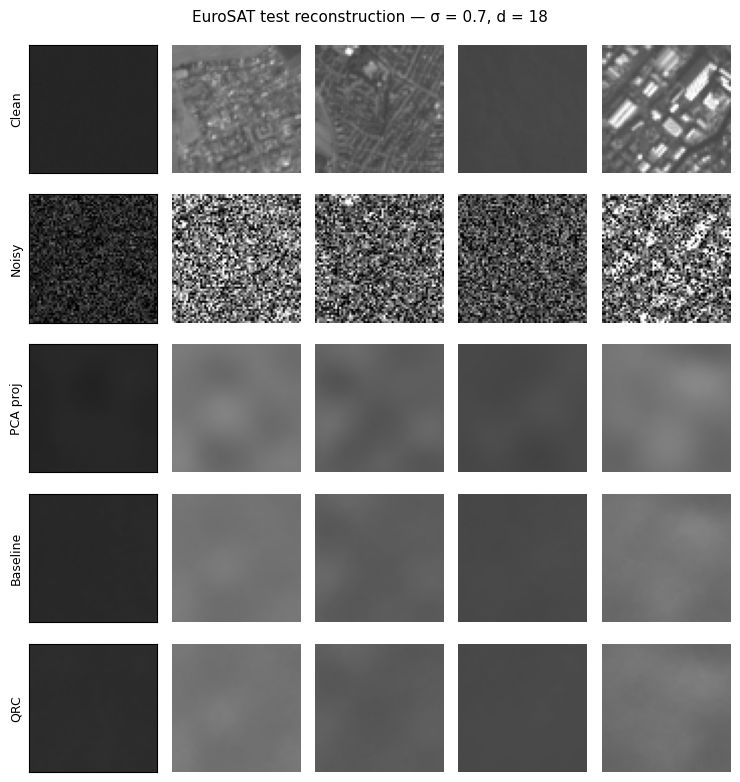

In [50]:
plots.image_rows(
    [(X_test[:5], "Clean"), (X_test_noisy[:5], "Noisy"), (_imgs(pca_recon_noisy)[:5], "PCA proj"),
     (_imgs(pred_baseline)[:5], "Baseline"), (_imgs(pred_hybrid)[:5], "QRC")],
    suptitle=f"EuroSAT test reconstruction — σ = {SIGMA}, d = {D_QRC}")

#### Diagnostic: top-ΔTENG images (not in the paper, backs §IV)

Images where the hybrid's TENG most exceeds the baseline's — the tail that drags the
mean ΔTENG positive. TENG rewards gradient energy, so residual noise inflates it: if
these hybrid outputs look noisy rather than sharp, the positive mean is spurious
sharpness, not perceptible detail.

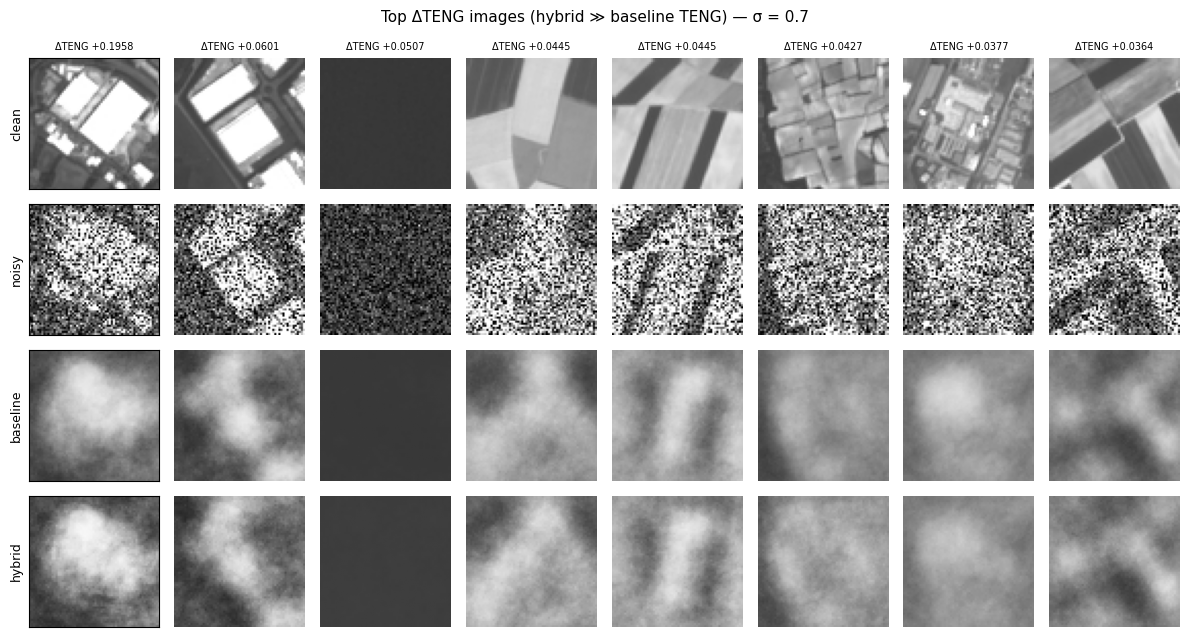

In [51]:
delta_teng = teng_per_image(pred_hybrid) - teng_per_image(pred_baseline)
top_idx = np.argsort(delta_teng)[-8:][::-1]
plots.image_rows(
    [(X_test[top_idx], "clean"), (X_test_noisy[top_idx], "noisy"),
     (_imgs(pred_baseline)[top_idx], "baseline"), (_imgs(pred_hybrid)[top_idx], "hybrid")],
    col_titles=[f"ΔTENG {delta_teng[i]:+.4f}" for i in top_idx],
    suptitle=f"Top ΔTENG images (hybrid ≫ baseline TENG) — σ = {SIGMA}")

### Save per-image metrics

One `.npz` per σ in `results/` (committed): per-image metric arrays for both models,
clean-image TENG, the PCA explained-variance ratio, and the showcase image panels used
by the paper's Fig. 2. `02_analysis.ipynb` consumes these files.

In [52]:
STATS_PATH = RESULTS_DIR / f"sigma{SIGMA}_per_image_metrics_d{D_QRC}.npz"
SHOWCASE_IDX = 4   # most textured of the first 5 test images

_sl = slice(SHOWCASE_IDX, SHOWCASE_IDX + 1)
np.savez(
    STATS_PATH,
    sigma=SIGMA,
    d_qrc=D_QRC,
    pca_evr=pca.explained_variance_ratio_,
    pc1_brightness_r=pc1_brightness_r,
    pc1_uniform_cos=pc1_uniform_cos,
    pc1_brightness_r_noisy=pc1_brightness_r_noisy,
    mse_hybrid=mse_per_image(pred_hybrid, y_test),
    mse_baseline=mse_per_image(pred_baseline, y_test),
    ssim_hybrid=ssim_per_image(pred_hybrid, y_test),
    ssim_baseline=ssim_per_image(pred_baseline, y_test),
    teng_hybrid=teng_per_image(pred_hybrid),
    teng_baseline=teng_per_image(pred_baseline),
    teng_clean=teng_per_image(y_test),
    # showcase panels (flat 4096; reshape 64×64 at plot time)
    showcase_idx=SHOWCASE_IDX,
    showcase_clean=X_test[SHOWCASE_IDX].ravel(),
    showcase_noisy=X_test_noisy[SHOWCASE_IDX].ravel(),
    showcase_pca=pca_recon_noisy[SHOWCASE_IDX],
    showcase_baseline=pred_baseline[SHOWCASE_IDX],
    showcase_hybrid=pred_hybrid[SHOWCASE_IDX],
    showcase_ssim_pca=ssim_per_image(pca_recon_noisy[_sl], y_test[_sl])[0],
    showcase_ssim_baseline=ssim_per_image(pred_baseline[_sl], y_test[_sl])[0],
    showcase_ssim_hybrid=ssim_per_image(pred_hybrid[_sl], y_test[_sl])[0],
)
print(f"Saved per-image metrics + showcase panels to {STATS_PATH}")

Saved per-image metrics + showcase panels to results/sigma0.7_per_image_metrics_d18.npz


---
Rerun this notebook for the remaining noise levels
(`QRC_SIGMA` ∈ {0.1, 0.3, 0.5, 0.7}), then open `02_analysis.ipynb`.